# Load and Filter


In [1]:
from pathlib import Path
import networkx as nx
import pandas as pd
import numpy as np

#Assumes cwd is folder directory
FOLDER = Path('./asnr datasets')
assert FOLDER.exists(), f"Dataset folder not found: {FOLDER}"

asnr_graphs: dict[str, nx.Graph] = {}
for fp in FOLDER.glob('*.graphml'):
    asnr_graphs[fp.stem + '.graphml'] = nx.read_graphml(fp)

info_frame = pd.read_csv(FOLDER / 'Network_summary_masterfile.csv')

selected_classes = ['Mammalia', 'Insecta', 'Aves']
selected_interactions = [
    'physical_contact',
    'social_projection_bipartite',
    'spatial_proximity',
    'grooming',
    'dominance',
    'FE_mating',
]


#FILTER to SELECTION
filtered_df = (
    info_frame[
        info_frame['interaction_type'].isin(selected_interactions) &
        info_frame['class'].isin(selected_classes) &
        (info_frame['nodes'] > 5) &
        pd.notna(info_frame['avg.edge.strength'])
    ]
    .copy()
    .rename(columns={'class': 'network_class'})
    .reset_index(drop=True)
)

interaction_mapping = {c: i for i, c in enumerate(selected_interactions)}
bio_class_mapping   = {c: i for i, c in enumerate(selected_classes)}
filtered_df['interaction_map'] = filtered_df['interaction_type'].map(interaction_mapping)

bio_inv         = {v: k for k, v in bio_class_mapping.items()}
interaction_inv = {v: k for k, v in interaction_mapping.items()}
bio_names       = [bio_inv[i] for i in sorted(bio_inv)]

print(f"Loaded {len(asnr_graphs)} graphs | Filtered: {len(filtered_df)}")


Loaded 1197 graphs | Filtered: 924


## Dataset overview

In [2]:
print("Biological class counts:")
print(filtered_df['network_class'].value_counts())
print("\nInteraction type counts:")
print(filtered_df['interaction_type'].value_counts())


Biological class counts:
network_class
Mammalia    516
Insecta     268
Aves        140
Name: count, dtype: int64

Interaction type counts:
interaction_type
social_projection_bipartite    288
physical_contact               270
spatial_proximity              153
grooming                       115
dominance                       50
FE_mating                       48
Name: count, dtype: int64


## Class x interaction type cross-tabulation

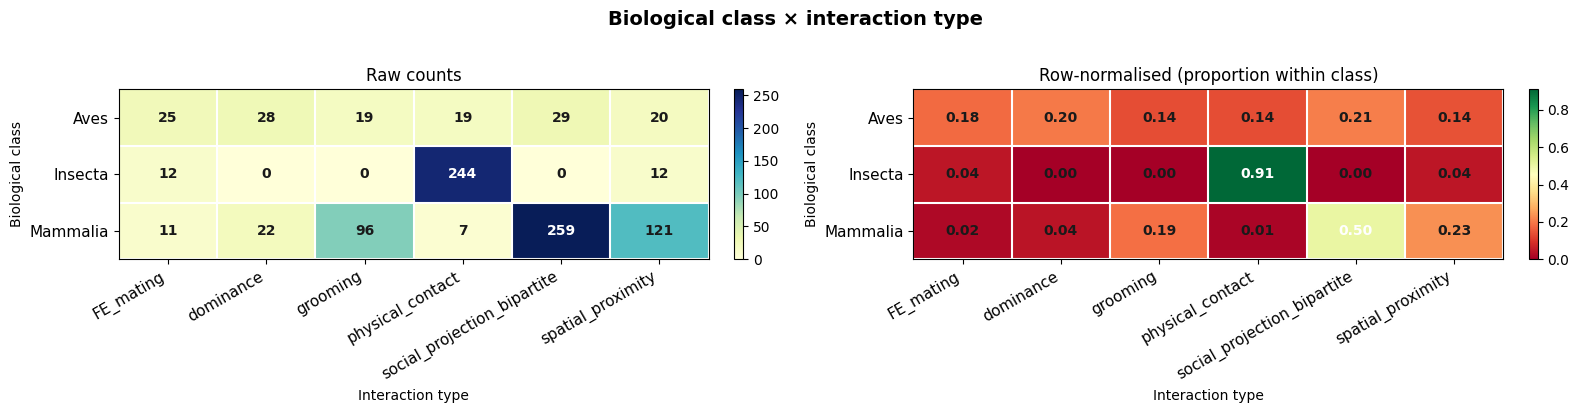

In [3]:
import matplotlib.pyplot as plt

crosstab = pd.crosstab(filtered_df['network_class'], filtered_df['interaction_type'])
crosstab_norm = crosstab.div(crosstab.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, data, fmt, title, cmap in zip(
    axes,
    [crosstab, crosstab_norm], ['d', '.2f'],
    ['Raw counts', 'Row-normalised (proportion within class)'],
    ['YlGnBu', 'RdYlGn'],
):
    im = ax.imshow(data.values, cmap=cmap, aspect='auto', vmin=0, vmax=data.values.max())
    ax.set_xticks(range(len(data.columns)))
    ax.set_yticks(range(len(data.index)))
    ax.set_xticklabels(data.columns, rotation=30, ha='right', fontsize=11)
    ax.set_yticklabels(data.index, fontsize=11)
    ax.set_xlabel('Interaction type'); ax.set_ylabel('Biological class')
    ax.set_title(title, fontsize=12)
    ax.set_xticks(np.arange(-0.5, len(data.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(data.index),   1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.tick_params(which='minor', bottom=False, left=False)
    vmax = data.values.max()
    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            v = data.values[i, j]
            ax.text(j, i, format(v, fmt), ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if v > 0.55 * vmax else '#1a1a1a')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Biological class × interaction type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
